<a href="https://colab.research.google.com/github/natitedros/WAVN-agentic-navigation/blob/main/poc_tests/grounding_dino_test_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing Grounding DINO on Gazebo images

Using a **GPU** (T4).

## 1. Install and check the GPU

In [13]:
!pip install -q -U transformers accelerate

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


## 2. Connect Google Drive and find the images


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

IMAGE_FOLDER = "/content/drive/MyDrive/tartanground/open_images_sample"
RESULTS_FOLDER = os.path.join(IMAGE_FOLDER, "grounding_dino_results_openimages")
os.makedirs(RESULTS_FOLDER, exist_ok=True)

with open(os.path.join(IMAGE_FOLDER, "labels.json")) as f:
    records = json.load(f)

# {image file: [objects in it]}, lowercase, only for images that exist in the folder
LABELS = {r["file"]: sorted({o.lower() for o in r["objects"]})
          for r in records
          if r["objects"] and os.path.exists(os.path.join(IMAGE_FOLDER, r["file"]))}
image_files = sorted(LABELS)

print(f"Found {len(image_files)} labelled images")
for f in image_files[:5]:
    print(f, LABELS[f])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20 labelled images
14a04785175a312c.jpg ['car', 'clothing', 'footwear', 'girl', 'jeans', 'tree', 'wheel']
1892326fce33bbbe.jpg ['plant', 'tree']
1beea2712bf5a333.jpg ['flag', 'golf ball', 'plant', 'sports equipment', 'tree']
1f8080f317918c0c.jpg ['house', 'human body', 'human nose', 'mammal', 'plant']
5de4dfef15a599cb.jpg ['car', 'dog', 'plant', 'tree']


## 3. Load the model

The first run downloads the model from Hugging Face (takes a minute). `tiny` is faster; `base` is more accurate.

In [15]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = "IDEA-Research/grounding-dino-tiny"   # or "IDEA-Research/grounding-dino-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
model.eval()
print("Model loaded on", device)

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Model loaded on cuda


## 4. Settings

- `OBJECT_PROMPTS`: the objects to look for. Use objects that actually appear in your environment.
- `BOX_THRESHOLD`: minimum confidence to keep a detection. Lower it to see weaker detections, raise it to cut false ones.
- `TEXT_THRESHOLD`: how strongly a detection must match the words. Usually leave as is.

In [16]:
OBJECT_PROMPTS = sorted({obj for objs in LABELS.values() for obj in objs})
print(len(OBJECT_PROMPTS), "prompts:", OBJECT_PROMPTS)

n_tokens = len(processor.tokenizer(". ".join(OBJECT_PROMPTS) + ".")["input_ids"])
print(f"Prompt length: {n_tokens} tokens (limit is 256)")

BOX_THRESHOLD = 0.5
TEXT_THRESHOLD = 0.25

37 prompts: ['alpaca', 'bed', 'building', 'cabbage', 'car', 'cattle', 'clothing', 'dog', 'flag', 'footwear', 'girl', 'glasses', 'golf ball', 'hat', 'horse', 'house', 'human body', 'human ear', 'human face', 'human hair', 'human hand', 'human head', 'human nose', 'jeans', 'land vehicle', 'mammal', 'man', 'person', 'plant', 'sports equipment', 'sunglasses', 'tire', 'tree', 'vehicle registration plate', 'wheel', 'window', 'woman']
Prompt length: 91 tokens (limit is 256)


## 5. Helper functions (detect and draw)

In [17]:
import time
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def load_image(fname):
    return Image.open(os.path.join(IMAGE_FOLDER, fname)).convert("RGB")


def detect(image, prompts, box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD):
    """Run Grounding DINO on one image. Returns (detections, seconds)."""
    inputs = processor(images=image, text=[prompts], return_tensors="pt").to(device)

    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        outputs = model(**inputs)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=[image.size[::-1]],
    )[0]

    labels = results.get("text_labels", results.get("labels"))
    detections = []
    for box, score, label in zip(results["boxes"], results["scores"], labels):
        detections.append({
            "label": label,
            "score": round(float(score), 3),
            "box": [round(float(v)) for v in box.tolist()],   # [x_min, y_min, x_max, y_max]
        })
    return detections, elapsed


def draw_detections(image, detections, title="", save_path=None, display=True):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)
    for d in detections:
        x0, y0, x1, y1 = d["box"]
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       fill=False, linewidth=2, edgecolor="lime"))
        ax.text(x0, max(y0 - 5, 0), f'{d["label"]} ({d["score"]:.2f})',
                color="black", fontsize=9, backgroundcolor="lime")
    ax.set_title(title)
    ax.axis("off")
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    if display:
        plt.show()
    plt.close(fig)

## 6. Try one image

14a04785175a312c.jpg: 9 detections in 686 ms
{'label': 'girl person woman', 'score': 0.574, 'box': [126, 141, 276, 474]}
{'label': 'car', 'score': 0.824, 'box': [33, 153, 195, 305]}
{'label': 'tire wheel', 'score': 0.539, 'box': [420, 455, 546, 619]}
{'label': 'land vehicle', 'score': 0.573, 'box': [230, 228, 938, 640]}
{'label': 'human nose', 'score': 0.743, 'box': [216, 173, 228, 188]}
{'label': 'human hand', 'score': 0.631, 'box': [207, 223, 244, 246]}
{'label': 'human ear', 'score': 0.623, 'box': [196, 162, 206, 177]}
{'label': 'human hair human head', 'score': 0.503, 'box': [168, 141, 240, 206]}
{'label': 'glasses sunglasses', 'score': 0.867, 'box': [204, 162, 237, 181]}


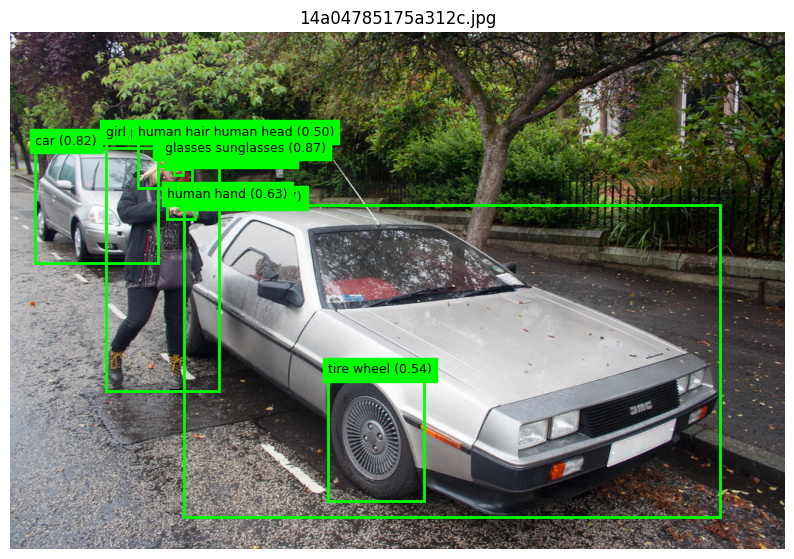

In [18]:
fname = image_files[0]
image = load_image(fname)

detect(image, OBJECT_PROMPTS)   # warm-up run (the first run is always slow)
dets, seconds = detect(image, OBJECT_PROMPTS)

print(f"{fname}: {len(dets)} detections in {seconds * 1000:.0f} ms")
for d in dets:
    print(d)
draw_detections(image, dets, fname)

## 7. Run on all images

Saves an annotated copy of every image and a CSV of all detections into `grounding_dino_results` inside your folder.

In [19]:
import pandas as pd

rows = []
for fname in image_files:
    image = load_image(fname)
    dets, seconds = detect(image, OBJECT_PROMPTS)

    if not dets:
        rows.append({"image": fname, "label": None, "score": None, "box": None,
                     "time_ms": round(seconds * 1000, 1)})
    for d in dets:
        rows.append({"image": fname, "label": d["label"], "score": d["score"],
                     "box": d["box"], "time_ms": round(seconds * 1000, 1)})

    draw_detections(image, dets, fname,
                    save_path=os.path.join(RESULTS_FOLDER, f"annotated_{os.path.splitext(fname)[0]}.png"),
                    display=False)

df = pd.DataFrame(rows)
df.to_csv(os.path.join(RESULTS_FOLDER, "detections_general_prompts.csv"), index=False)

print(f"Images processed: {len(image_files)}")
print(f"Total detections: {df['label'].notna().sum()}")
print(f"Average time per image: {df.groupby('image')['time_ms'].first().mean():.0f} ms")
df.head(20)

Images processed: 20
Total detections: 63
Average time per image: 599 ms


,image,label,score,box,time_ms
0,14a04785175a312c.jpg,girl person woman,0.574,"[126, 141, 276, 474]",725.1
1,14a04785175a312c.jpg,car,0.824,"[33, 153, 195, 305]",725.1
2,14a04785175a312c.jpg,tire wheel,0.539,"[420, 455, 546, 619]",725.1
3,14a04785175a312c.jpg,land vehicle,0.573,"[230, 228, 938, 640]",725.1
4,14a04785175a312c.jpg,human nose,0.743,"[216, 173, 228, 188]",725.1
5,14a04785175a312c.jpg,human hand,0.631,"[207, 223, 244, 246]",725.1
6,14a04785175a312c.jpg,human ear,0.623,"[196, 162, 206, 177]",725.1
7,14a04785175a312c.jpg,human hair human head,0.503,"[168, 141, 240, 206]",725.1
8,14a04785175a312c.jpg,glasses sunglasses,0.867,"[204, 162, 237, 181]",725.1
9,1892326fce33bbbe.jpg,None,NaN,None,706.6


## 8. Check against what's really in each image (optional, but most useful)

Fill in `EXPECTED` with the objects that are actually in each image (use the same wording as `OBJECT_PROMPTS`). You don't have to list every image; unlisted ones are skipped.

This answers two questions:
1. **Did it find the right objects?** (found / missed / extra)
2. **Are the confidence scores meaningful?** Correct detections should have clearly higher scores than wrong ones. Your clarifying-question idea depends on this.

In [20]:
EXPECTED = LABELS

def normalize(text):
    text = (text or "").lower().strip()
    for article in ("a ", "an ", "the "):
        if text.startswith(article):
            text = text[len(article):]
    return text


import re

def is_match(detected, expected):
    d, e = normalize(detected), normalize(expected)
    if not d or not e:
        return False
    whole = lambda small, big: re.search(rf"\b{re.escape(small)}\b", big) is not None
    return whole(e, d) or whole(d, e)


summary_rows = []
correct_scores, wrong_scores = [], []

for fname, expected_objects in EXPECTED.items():
    image_dets = df[(df["image"] == fname) & df["label"].notna()]
    found, missed = [], []
    for obj in expected_objects:
        (found if any(is_match(l, obj) for l in image_dets["label"]) else missed).append(obj)

    extra = []
    for _, row in image_dets.iterrows():
        if any(is_match(row["label"], obj) for obj in expected_objects):
            correct_scores.append(row["score"])
        else:
            wrong_scores.append(row["score"])
            extra.append(f'{row["label"]} ({row["score"]:.2f})')

    summary_rows.append({"image": fname, "found": found, "missed": missed, "extra": extra})

if summary_rows:
    summary = pd.DataFrame(summary_rows)
    summary.to_csv(os.path.join(RESULTS_FOLDER, "accuracy_check.csv"), index=False)

    total_expected = sum(len(v) for v in EXPECTED.values())
    total_found = sum(len(r["found"]) for r in summary_rows)
    print(f"Found {total_found} of {total_expected} expected objects "
          f"({100 * total_found / max(total_expected, 1):.0f}%)")
    print(f"Wrong (extra) detections: {len(wrong_scores)}")
    if correct_scores:
        print(f"Average score, correct detections: {sum(correct_scores) / len(correct_scores):.2f}")
    if wrong_scores:
        print(f"Average score, wrong detections:   {sum(wrong_scores) / len(wrong_scores):.2f}")
    display(summary)
else:
    print("Fill in EXPECTED above first.")

Found 24 of 84 expected objects (29%)
Wrong (extra) detections: 27
Average score, correct detections: 0.63
Average score, wrong detections:   0.63


,image,found,missed,extra
0,a0922dbd2cb47589.jpg,"[car, wheel]",[tree],"[vehicle registration plate (0.83), human head..."
1,770522297d5bcaae.jpg,[],[tree],[]
2,65fa93cf7916e533.jpg,[person],"[cattle, human head, mammal]","[glasses sunglasses (0.69), jeans (0.65), huma..."
3,f87521aaee29e922.jpg,[house],"[tree, window]",[]
4,c29e93d5ccc965ff.jpg,[],"[tree, window]",[]
5,1f8080f317918c0c.jpg,[],"[house, human body, human nose, mammal, plant]",[]
6,1beea2712bf5a333.jpg,"[flag, golf ball]","[plant, sports equipment, tree]",[]
7,718c6a002b97f568.jpg,[],"[cabbage, plant, tree]",[building house (0.55)]
8,66b7a5e867c39982.jpg,[],[tree],[]
9,833212810ef0c76b.jpg,"[horse, person]","[mammal, tree]","[human hand (0.62), land vehicle (0.65), glass..."


## 9. Specific prompts (the kind your path-finding agent will send)

Asking for things like *"a blue mailbox next to a garage door"*, not just *"a mailbox"*. Test that here.

Include some **decoy** prompts too: objects that are *not* in the image. If the model returns high scores for things that aren't there, that's important to know before you trust its confidence.

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


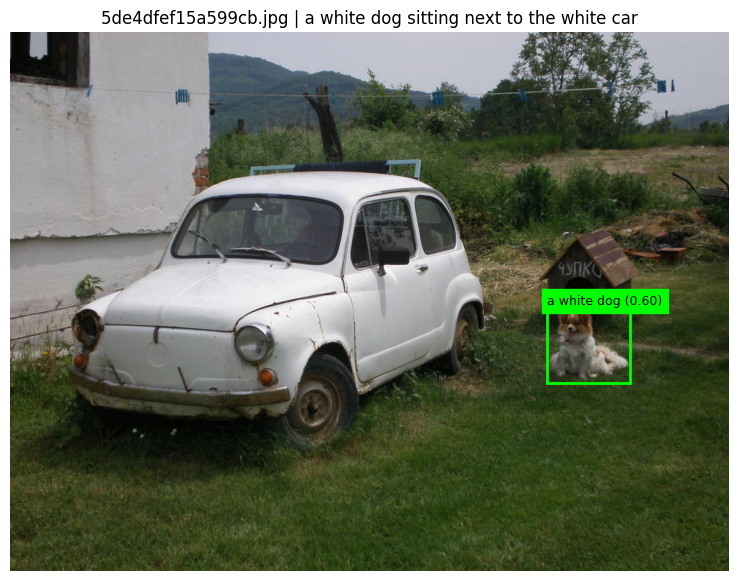

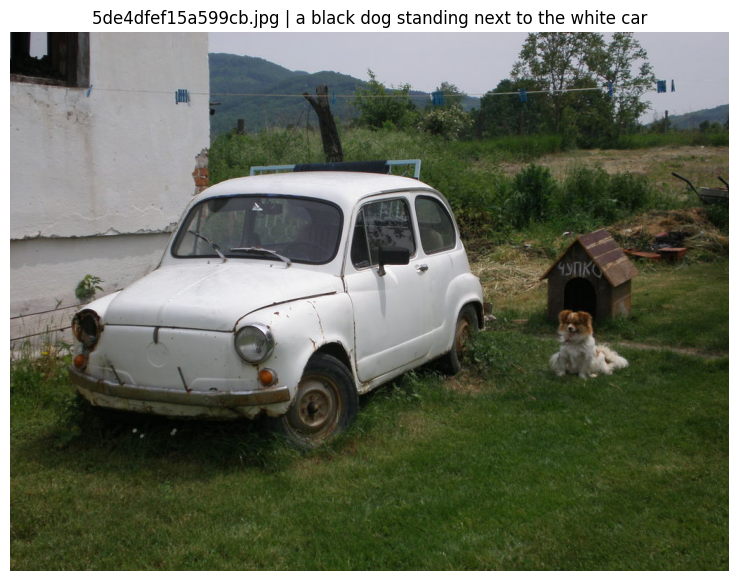

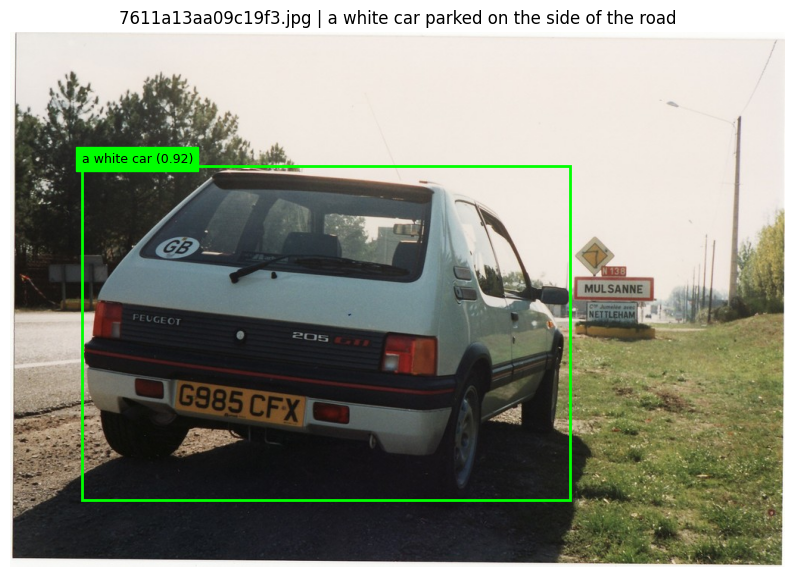

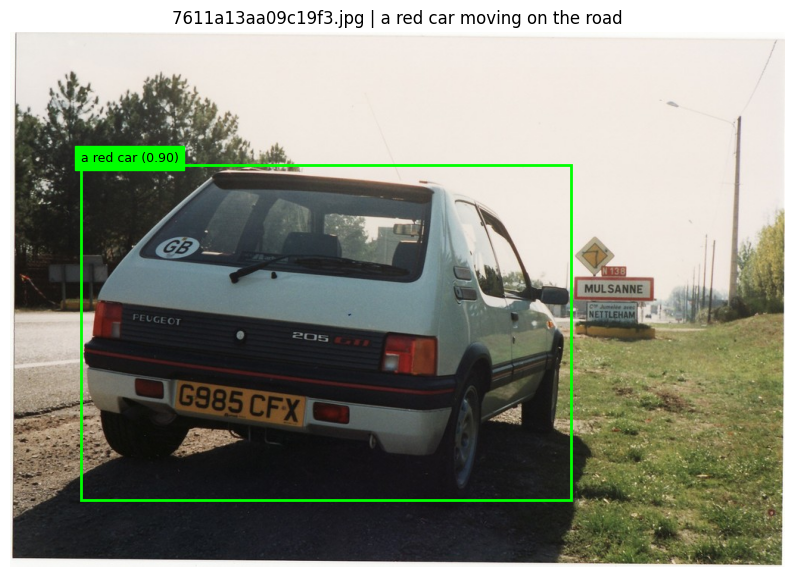

,image,prompt,really_there,detections,best_score
0,5de4dfef15a599cb.jpg,a white dog sitting next to the white car,True,1,0.602
1,5de4dfef15a599cb.jpg,a black dog standing next to the white car,False,0,0.000
2,7611a13aa09c19f3.jpg,a white car parked on the side of the road,True,1,0.915
3,7611a13aa09c19f3.jpg,a red car moving on the road,False,1,0.904


In [25]:
SPECIFIC_TESTS = [                              # <-- EDIT: (image file, prompt, is it really there?)
    ("5de4dfef15a599cb.jpg", "a white dog sitting next to the white car", True),
    ("5de4dfef15a599cb.jpg", "a black dog standing next to the white car", False), # decoy
    ("7611a13aa09c19f3.jpg", "a white car parked on the side of the road", True),
    ("7611a13aa09c19f3.jpg", "a red car moving on the road", False), # decoy
]

specific_rows = []
for fname, prompt, really_there in SPECIFIC_TESTS:
    image = load_image(fname)
    dets, _ = detect(image, [prompt])
    best = max((d["score"] for d in dets), default=0.0)
    specific_rows.append({"image": fname, "prompt": prompt, "really_there": really_there,
                          "detections": len(dets), "best_score": best})
    draw_detections(image, dets, f"{fname} | {prompt}")

if specific_rows:
    specific_df = pd.DataFrame(specific_rows)
    specific_df.to_csv(os.path.join(RESULTS_FOLDER, "specific_prompt_tests.csv"), index=False)
    display(specific_df)
else:
    print("Fill in SPECIFIC_TESTS above first.")

## 10. Save object crops for Step 3 (BLIP-2)

Saves each detected object as its own small image. In Step 3, BLIP-2 will describe these crops, which is exactly what the perception agent does.

In [26]:
CROPS_FOLDER = os.path.join(RESULTS_FOLDER, "crops")
os.makedirs(CROPS_FOLDER, exist_ok=True)

crop_count = 0
for fname in image_files:
    image = load_image(fname)
    image_dets = df[(df["image"] == fname) & df["label"].notna()]
    for i, (_, row) in enumerate(image_dets.iterrows()):
        x0, y0, x1, y1 = row["box"]
        crop = image.crop((x0, y0, x1, y1))
        label = normalize(row["label"]).replace(" ", "_") or "object"
        crop.save(os.path.join(CROPS_FOLDER,
                               f"{os.path.splitext(fname)[0]}_{i}_{label}_{row['score']:.2f}.png"))
        crop_count += 1

print(f"Saved {crop_count} crops to {CROPS_FOLDER}")

Saved 63 crops to /content/drive/MyDrive/tartanground/open_images_sample/grounding_dino_results_openimages/crops
